# Notebook 07: Evaluation Benchmark

## Purpose
Run the full ablation grid across all combinations of embedding model, LLM, and RAG condition. Results accumulate in `models/benchmarks.json`, already completed runs are skipped automatically so the notebook is safe to restart.

## Grid
2 embedding models × 2 LLMs × 2 RAG conditions = **8 combinations**

| # | Embedding | LLM | RAG | Run ID |
|---|---|---|---|---|
| 1 | Qwen3-Embedding-0.6B | Qwen3-4B | ✗ | `qwen3-embedding-0.6b__qwen3-4b__no-rag` |
| 2 | Qwen3-Embedding-0.6B | Qwen3-4B | ✓ | `qwen3-embedding-0.6b__qwen3-4b__rag` |
| 3 | Qwen3-Embedding-0.6B | Qwen3-4B-Thinking | ✗ | `qwen3-embedding-0.6b__qwen3-4b-thinking-2507__no-rag` |
| 4 | Qwen3-Embedding-0.6B | Qwen3-4B-Thinking | ✓ | `qwen3-embedding-0.6b__qwen3-4b-thinking-2507__rag` |
| 5 | Octen-Embedding-0.6B | Qwen3-4B-Thinking | ✗ | `octen-embedding-0.6b__qwen3-4b-thinking-2507__no-rag` |
| 6 | Octen-Embedding-0.6B | Qwen3-4B-Thinking | ✓ | `octen-embedding-0.6b__qwen3-4b-thinking-2507__rag` |

Runs 1–2 completed in notebook 04 (pilot, 50 questions, Qwen3-4B standard).
Runs 3–6 completed in notebook 07 (full ablation, 100 questions, Qwen3-4B-Thinking).

## Status
All 6 runs complete. See `models/benchmarks.json` for raw results.

## Benchmark Reference
AMG-RAG: 74.1% F1 on MedQA (GPT-4o-mini + dynamic PubMed KG).

## Outputs
```
models/benchmarks.json             # cumulative results + committed to git
models/eval_checkpoints/*.parquet  # per-question progress + gitignored
```

## 0. Environment Setup

In [1]:
import gc
import sys
import json
import os
import re
import shutil
import warnings
from datetime import date
from itertools import groupby
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive, userdata
    HF_TOKEN = userdata.get('HF_TOKEN')

    if not Path('/content/emma').exists():
        os.system('git clone https://github.com/jaxendutta/emma.git')
    os.chdir('/content/emma')

    os.system('pip install -e . -q')
    os.system('pip install transformers accelerate bitsandbytes faiss-cpu sentence-transformers -q')
    os.system(
        'pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz -q'
    )

    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/emma')
else:
    HF_TOKEN = os.environ.get('HF_TOKEN') or None
    ROOT = None  # set after import

from src.data import REPO_ROOT, load_medqa
from src.retrieval import (
    EMMARetriever,
    _load_models_config,
    get_embedding_config,
    get_model_config,
)

if ROOT is None:
    ROOT = REPO_ROOT

BENCH_PATH = ROOT / 'models' / 'benchmarks.json'
CKPT_DIR   = ROOT / 'models' / 'eval_checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Environment     : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Repo root       : {REPO_ROOT}')
print(f'Benchmarks file : {BENCH_PATH}')
print(f'HF token        : {"set" if HF_TOKEN else "not set"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment     : Google Colab
Repo root       : /content/emma
Benchmarks file : /content/drive/MyDrive/emma/models/benchmarks.json
HF token        : set


In [2]:
if IN_COLAB:
    for artifact in ['classifier']:
        src = ROOT / 'models' / artifact
        dst = REPO_ROOT / 'models' / artifact
        dst.mkdir(parents=True, exist_ok=True)
        if src.exists():
            for f in src.glob('*'):
                if f.is_file():
                    shutil.copy(f, dst / f.name)
        print(f'> Restored {artifact} : {[f.name for f in dst.glob("*")]}')

    for emb in _load_models_config().get('embeddings_models', []):
        src = ROOT / 'models' / 'vectorstore' / emb['id']
        dst = REPO_ROOT / 'models' / 'vectorstore' / emb['id']
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            for f in src.glob('*'):
                if f.is_file():
                    shutil.copy(f, dst / f.name)
            print(f'✓ Restored vectorstore/{emb["id"]} : {[f.name for f in dst.glob("*")]}')
        else:
            print(f'> vectorstore/{emb["id"]} not on Drive! Runs using this embedding will be skipped.')

    bench_local = REPO_ROOT / 'models' / 'benchmarks.json'
    if BENCH_PATH.exists():
        shutil.copy(BENCH_PATH, bench_local)
        n_done = len([r for r in json.loads(bench_local.read_text())['runs']
                      if r.get('status') == 'complete'])
        print(f'✓ Restored benchmarks.json : {n_done} complete runs')

    ckpt_local = REPO_ROOT / 'models' / 'eval_checkpoints'
    ckpt_local.mkdir(parents=True, exist_ok=True)
    n_ckpts = 0
    for f in CKPT_DIR.glob('*.parquet'):
        shutil.copy(f, ckpt_local / f.name)
        n_ckpts += 1
    if n_ckpts:
        print(f'✓ Restored {n_ckpts} checkpoint(s) — runs will resume mid-question.')

> Restored classifier : ['config.json', 'tfidf_svm.pkl', 'medqa_with_specialty.parquet', 'label_encoder.pkl']
> vectorstore/all-MiniLM-L12-v2 not on Drive! Runs using this embedding will be skipped.
✓ Restored vectorstore/qwen3-embedding-0.6b : ['config.json', 'texts.pkl', 'metadata.pkl', 'index.faiss']
✓ Restored vectorstore/octen-embedding-0.6b : ['config.json', 'texts.pkl', 'metadata.pkl', 'index.faiss']
✓ Restored benchmarks.json : 0 complete runs


## 1. Grid Definition

All combinations are derived from `config/models.json` and `models/benchmarks.json`.

In [3]:
bench         = json.loads(BENCH_PATH.read_text())
completed_ids = {r['id'] for r in bench['runs'] if r.get('status') == 'complete'}

combinations = _load_models_config().get('benchmark_combinations', [])

all_runs = []
for combo in combinations:
    emb_cfg = get_embedding_config(combo['embedding'])
    llm_cfg = get_model_config(combo['llm'])
    for rag in combo['rag']:
        suffix = 'rag' if rag else 'no-rag'
        rid    = f"{combo['embedding']}__{combo['llm']}__{suffix}"
        all_runs.append({
            'id':  rid,
            'emb': emb_cfg,
            'llm': llm_cfg,
            'rag': rag,
        })

pending = [r for r in all_runs if r['id'] not in completed_ids]

grid_df = pd.DataFrame([
    {
        'Run ID':    r['id'],
        'Embedding': r['emb']['name'],
        'LLM':       r['llm']['name'],
        'RAG':       '✓' if r['rag'] else '✗',
        'Status':    '✓ Done' if r['id'] in completed_ids else '⚠ Pending',
    }
    for r in all_runs
])

print(f'Total : {len(all_runs)}  |  Done : {len(completed_ids)}  |  Pending : {len(pending)}')
display(grid_df)

Total : 2  |  Done : 0  |  Pending : 2


,Run ID,Embedding,LLM,RAG,Status
0,octen-embedding-0.6b__qwen3-4b-thinking-2507__rag,Octen Embedding 0.6B,Qwen3 4B Thinking 2507,✓,⚠ Pending
1,octen-embedding-0.6b__qwen3-4b-thinking-2507__...,Octen Embedding 0.6B,Qwen3 4B Thinking 2507,✗,⚠ Pending


## 2. Evaluation Setup

In [4]:
def extract_answer_letter(response: str, options: dict) -> str | None:
    """
    Extract predicted answer letter (A/B/C/D) from LLM response.
    Strips thinking tokens, tries patterns in priority order,
    falls back to option text matching.
    """
    response = re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()
    patterns = [
        r'(?:answer is|answer:|correct answer is|correct option is)\s*:?\s*([A-D])',
        r'^\s*([A-D])[.):\s]',
        r'(?:therefore|thus|so|hence)[^A-D]{0,20}([A-D])\s+(?:is|would be|appears)',
        r'(?:option|choice)\s+([A-D])\b',
        r'\b([A-D])\s+is\s+(?:correct|the answer|most likely)',
        r'\b([A-D])\b',
    ]
    for pattern in patterns:
        m = re.search(pattern, response, re.IGNORECASE | re.MULTILINE)
        if m:
            return m.group(1).upper()
    for letter, text in options.items():
        if str(text).lower()[:40] in response.lower():
            return letter.upper()
    return None

In [5]:
N_EVAL      = 100
RANDOM_SEED = 42

medqa_test = load_medqa(split='test')
eval_df    = medqa_test.sample(
    n=min(N_EVAL, len(medqa_test)), random_state=RANDOM_SEED
).reset_index(drop=True)

print(f'> Questions per run : {len(eval_df)}')
print(f'> Pending runs      : {len(pending)}')
print(f'> Est. total calls  : ~{len(eval_df) * len(pending)}')
display(eval_df[['question', 'answer']].head(3))

[MedQA] Loaded 1,273 rows  (split=test)
> Questions per run : 100
> Pending runs      : 2
> Est. total calls  : ~200


,question,answer
0,A healthy 23-year-old male is undergoing an ex...,Coronary sinus
1,A 31-year-old female patient presents with sig...,Psoriatic arthritis
2,A 47-year-old woman comes to the physician bec...,Intrafascicular infiltration on muscle biopsy


## 3. Ablation Grid

- Outer loop: embedding model; reloads vectorstore only when the embedding changes.
- Inner loop: LLM × RAG; hot-swaps the LLM via `retriever.switch_model()`.
- Checkpoint written after every question; copied to Drive after every completed run.
- Re-run this cell at any time to resume; already-done runs are always skipped.

In [9]:
def _save_bench(bench: dict) -> None:
    BENCH_PATH.write_text(json.dumps(bench, indent=2))

In [12]:
def _run_eval(
    retriever,
    eval_df: pd.DataFrame,
    use_rag: bool,
    checkpoint: Path,
) -> dict:
    """
    Evaluate one (LLM, RAG-condition) pair with per-question checkpointing.
    Automatically resumes from checkpoint if it already exists.
    Returns a result dict for benchmarks.json.
    """
    rows = []
    if checkpoint.exists():
        rows = pd.read_parquet(checkpoint).to_dict('records')
        print(f'  Resuming: {len(rows)} / {len(eval_df)} questions already done')

    done_qs   = {r['question'] for r in rows}
    remaining = eval_df[~eval_df['question'].str[:100].isin(done_qs)].copy()

    bar_fmt = '    {l_bar}{bar}| {n:,}/{total:,} [{elapsed}<{remaining}]  {postfix}'
    pbar    = tqdm(remaining.iterrows(), total=len(remaining),
                   unit=' q', bar_format=bar_fmt)

    for _, row in pbar:
        q        = row['question']
        options  = row['options']
        correct  = str(row['answer_idx']).upper()
        opts_str = '\n'.join(f"{k}. {v}" for k, v in options.items())
        full_q   = f"{q}\n\nOptions:\n{opts_str}"

        try:
            model_cfg  = get_model_config(retriever.model_id)
            think      = model_cfg.get('thinking', False)
            res        = retriever.answer(full_q, use_rag=use_rag, think=think, max_new_tokens=2048)
            pred       = extract_answer_letter(res.answer, options)
            is_correct = pred == correct if pred else False
        except Exception:
            res, pred, is_correct = None, None, False

        rows.append({
            'question':   q[:100],
            'correct':    correct,
            'pred':       pred,
            'is_correct': is_correct,
            'top_score':  res.metadata.get('top_score') if res else None,
            'latency_s':  res.latency_s if res else None,
        })

        n   = len(rows)
        acc = sum(r['is_correct'] for r in rows) / n * 100
        pbar.set_postfix_str(f'acc={acc:.1f}%')

        pd.DataFrame(rows).to_parquet(checkpoint, index=False)

    df  = pd.DataFrame(rows)
    acc = df['is_correct'].mean() * 100
    return {
        'accuracy':       round(acc / 100, 4),
        'mean_top_score': round(float(df['top_score'].dropna().mean()), 4)
                          if use_rag and df['top_score'].notna().any() else None,
        'n_eval':         len(df),
        '_df':            df,
    }

In [13]:
# ── Main ablation loop ────────────────────────────────────────────────────────
bench         = json.loads(BENCH_PATH.read_text())
completed_ids = {r['id'] for r in bench['runs'] if r.get('status') == 'complete'}

cfg_data     = _load_models_config()
combinations = cfg_data.get('benchmark_combinations', [])

all_runs = []
for combo in combinations:
    emb_cfg = get_embedding_config(combo['embedding'])
    llm_cfg = get_model_config(combo['llm'])
    for rag in combo['rag']:
        suffix = 'rag' if rag else 'no-rag'
        rid    = f"{combo['embedding']}__{combo['llm']}__{suffix}"
        all_runs.append({
            'id':     rid,
            'emb':    emb_cfg,
            'llm':    llm_cfg,
            'rag':    rag,
            'n_eval': combo.get('n_eval', N_EVAL),
        })

print(f'Grid: {len(all_runs)} combinations ({len([r for r in all_runs if r["id"] in completed_ids])} already done)')
for run in all_runs:
    status = '✓ Done' if run['id'] in completed_ids else '⚠ Pending'
    print(f'  [{status}] {run["id"]}')

current_emb_id = None
retriever      = None

for run in all_runs:
    rid     = run['id']
    emb_cfg = run['emb']
    llm_cfg = run['llm']
    rag     = run['rag']
    n_eval  = run['n_eval']

    if rid in completed_ids:
        print(f'\n  ✓ Already done: {rid}')
        continue

    # ── Recover from disk ──────────────────────────────────────────────────────
    run_dir     = ROOT / 'models' / 'evaluation' / f'{emb_cfg["id"]}__{llm_cfg["id"]}'
    config_path = run_dir / 'config.json'

    # Full merge already done
    if config_path.exists() and (run_dir / 'results.parquet').exists():
        cfg       = json.loads(config_path.read_text())
        accuracy  = cfg['rag_accuracy'] / 100 if rag else cfg['base_accuracy'] / 100
        top_score = cfg['mean_top_score'] if rag else None
        bench['runs'].append({
            'id':             rid,
            'embedding':      emb_cfg['id'],
            'llm':            llm_cfg['id'],
            'rag':            rag,
            'n_eval':         cfg['n_eval'],
            'accuracy':       accuracy,
            'mean_top_score': top_score,
            'status':         'complete',
            'timestamp':      cfg.get('timestamp', str(date.today())),
            'notes':          'Recovered from disk',
        })
        _save_bench(bench)
        completed_ids.add(rid)
        print(f'     ✓ Recovered: {accuracy * 100:.1f}%')
        continue

    # Temp file exists — this condition's eval is done but paired run isn't yet
    parquet_file = 'rag_results.parquet' if rag else 'base_results.parquet'
    if (run_dir / parquet_file).exists():
        print(f'\n  ✓ Already evaluated (awaiting paired condition): {rid}')
        completed_ids.add(rid)
        continue

    # ── Hot-load or swap embedding/LLM as needed ──────────────────────────────
    if current_emb_id != emb_cfg['id']:
        print(f'\n  > Loading pipeline for {emb_cfg["name"]}...')
        retriever      = EMMARetriever.load(
            model_id=llm_cfg['id'],
            emb_model_name=emb_cfg['id'],
            hf_token=HF_TOKEN,
        )
        current_emb_id = emb_cfg['id']
    elif retriever.model_id != llm_cfg['id']:
        retriever.switch_model(llm_cfg['id'])

    label = f"{llm_cfg['name']}  |  RAG={'ON' if rag else 'OFF'}"
    print(f'\n  >> {label}\n     {rid}')

    checkpoint  = CKPT_DIR / f'{rid}.parquet'
    result      = _run_eval(retriever, eval_df.head(n_eval), rag, checkpoint)

    # ── Persist results ────────────────────────────────────────────────────────
    run_dir.mkdir(parents=True, exist_ok=True)

    # Save this condition's results as a temp file
    parquet_file = 'rag_results.parquet' if rag else 'base_results.parquet'
    result['_df'].to_parquet(run_dir / parquet_file, index=False)

    # Check if the paired condition is also done
    paired_file = 'base_results.parquet' if rag else 'rag_results.parquet'

    if (run_dir / paired_file).exists():
        # ── Both conditions complete — merge and write full config ─────────────
        rag_df   = pd.read_parquet(run_dir / 'rag_results.parquet')
        base_df  = pd.read_parquet(run_dir / 'base_results.parquet')

        results  = rag_df.merge(
            base_df[['question', 'is_correct', 'pred', 'latency_s']],
            on='question', suffixes=('_rag', '_base'),
        )
        results.to_parquet(run_dir / 'results.parquet', index=False)

        # Clean up temp files
        (run_dir / 'rag_results.parquet').unlink(missing_ok=True)
        (run_dir / 'base_results.parquet').unlink(missing_ok=True)

        rag_acc   = results['is_correct_rag'].mean() * 100
        base_acc  = results['is_correct_base'].mean() * 100
        scores    = rag_df['top_score'].dropna()

        run_config = {
            'embedding':      emb_cfg['id'],
            'llm':            llm_cfg['id'],
            'n_eval':         len(results),
            'rag_accuracy':   round(rag_acc, 2),
            'base_accuracy':  round(base_acc, 2),
            'delta':          round(rag_acc - base_acc, 2),
            'mean_top_score': round(float(scores.mean()), 4) if len(scores) > 0 else None,
            'rag_helped':     int((results['is_correct_rag'] & ~results['is_correct_base']).sum()),
            'rag_hurt':       int((~results['is_correct_rag'] & results['is_correct_base']).sum()),
            'timestamp':      str(date.today()),
        }
        print(f'     ✓ Merged results.parquet ({len(results)} questions)')
    else:
        # ── Only one condition done — write partial config ─────────────────────
        existing_cfg = json.loads(config_path.read_text()) if config_path.exists() else {}
        new_fields   = {
            'rag_accuracy':   round(result['accuracy'] * 100, 2),
            'mean_top_score': result['mean_top_score'],
        } if rag else {
            'base_accuracy':  round(result['accuracy'] * 100, 2),
        }
        run_config = {
            **existing_cfg,
            'embedding':  emb_cfg['id'],
            'llm':        llm_cfg['id'],
            'n_eval':     result['n_eval'],
            'timestamp':  str(date.today()),
            **new_fields,
        }

    config_path.write_text(json.dumps(run_config, indent=2))

    # ── Append to benchmarks.json ─────────────────────────────────────────────
    bench['runs'].append({
        'id':             rid,
        'embedding':      emb_cfg['id'],
        'llm':            llm_cfg['id'],
        'rag':            rag,
        'n_eval':         result['n_eval'],
        'accuracy':       result['accuracy'],
        'mean_top_score': result['mean_top_score'],
        'status':         'complete',
        'timestamp':      str(date.today()),
        'notes':          'Notebook 07 ablation grid',
    })
    _save_bench(bench)
    completed_ids.add(rid)

    acc_str   = f"{result['accuracy'] * 100:.1f}%"
    score_str = f"  mean score={result['mean_top_score']:.4f}" if result['mean_top_score'] else ''
    print(f'     ✓ Accuracy: {acc_str}{score_str}')
    print(f'     ✓ Saved  : {run_dir / parquet_file}')

pending_remaining = [r for r in all_runs if r['id'] not in completed_ids]
if pending_remaining:
    print(f'\n{len(pending_remaining)} run(s) still pending:')
    for r in pending_remaining: print(f'  {r["id"]}')
else:
    print('\n✓ All runs complete.')

Grid: 2 combinations (0 already done)
  [⚠ Pending] octen-embedding-0.6b__qwen3-4b-thinking-2507__rag
  [⚠ Pending] octen-embedding-0.6b__qwen3-4b-thinking-2507__no-rag

  > Loading pipeline for Octen Embedding 0.6B...
> Loading vectorstore (qwen3-4b-thinking-2507)...
[Vectorstore] Loaded index: 36,723 vectors from /content/emma/models/vectorstore/octen-embedding-0.6b
[Vectorstore] Loaded 36,723 chunk texts from /content/emma/models/vectorstore/octen-embedding-0.6b
> Loading embedding model (Octen/Octen-Embedding-0.6B)...
[Vectorstore] GPU memory: 5.7 GB free / 14.6 GB total


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[Vectorstore] Embedding model: Octen/Octen-Embedding-0.6B  (dtype=torch.float16, device=cuda)
> Loading specialty classifier (en_ner_bc5cdr_md)...
> Loading SpaCy NER model (en_ner_bc5cdr_md)...
EMMA retriever ready. Ollama not running — primary: HuggingFace (Qwen/Qwen3-4B-Thinking-2507)
  To use Ollama: ollama pull qwen3:4b-thinking-2507-q4_K_M
> Pre-loading HuggingFace model as fallback...
> Loading Qwen3 4B Thinking 2507 (Qwen/Qwen3-4B-Thinking-2507) in 4-bit nf4...
  GPU: Tesla T4  (14.6 GB VRAM)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  Loaded on cuda:0. VRAM used: 8.7 GB

  >> Qwen3 4B Thinking 2507  |  RAG=ON
     octen-embedding-0.6b__qwen3-4b-thinking-2507__rag
  Resuming: 1 / 100 questions already done


    100%|██████████| 99/99 [47:26<00:00]  , acc=13.0%


     ✓ Accuracy: 13.0%  mean score=0.6386
     ✓ Saved  : /content/drive/MyDrive/emma/models/evaluation/octen-embedding-0.6b__qwen3-4b-thinking-2507/rag_results.parquet

  >> Qwen3 4B Thinking 2507  |  RAG=OFF
     octen-embedding-0.6b__qwen3-4b-thinking-2507__no-rag


    100%|██████████| 100/100 [1:39:37<00:00]  , acc=32.0%

     ✓ Merged results.parquet (100 questions)
     ✓ Accuracy: 32.0%
     ✓ Saved  : /content/drive/MyDrive/emma/models/evaluation/octen-embedding-0.6b__qwen3-4b-thinking-2507/base_results.parquet

✓ All runs complete.


## 4. Results

### 4.1. Overall Performance

In [14]:
bench      = json.loads(BENCH_PATH.read_text())
cfg        = _load_models_config()
emb_names  = {m['id']: m['name'] for m in cfg['embeddings_models']}
llm_names  = {m['id']: m['name'] for m in cfg['models']}

runs       = [r for r in bench['runs'] if r.get('status') == 'complete']
results_df = pd.DataFrame(runs)
results_df['Embedding'] = results_df['embedding'].map(emb_names)
results_df['LLM']       = results_df['llm'].map(llm_names)
results_df['RAG']       = results_df['rag'].map({True: '✓', False: '✗'})

display_df = (
    results_df[['Embedding', 'LLM', 'RAG', 'accuracy', 'mean_top_score', 'n_eval']]
    .assign(accuracy=lambda d: (d['accuracy']))
    .rename(columns={
        'accuracy':       'Accuracy %',
        'mean_top_score': 'Mean retrieval score',
        'n_eval':         'N',
    })
    .sort_values(['Embedding', 'LLM', 'RAG'])
    .reset_index(drop=True)
)

display(display_df)

,Embedding,LLM,RAG,Accuracy %,Mean retrieval score,N
0,Octen Embedding 0.6B,Qwen3 4B Thinking 2507,✓,0.13,0.6386,100
1,Octen Embedding 0.6B,Qwen3 4B Thinking 2507,✗,0.32,NaN,100


### 4.2. RAG Delta Table

In [15]:
# RAG delta table: for each (embedding, LLM) pair, RAG accuracy - baseline accuracy
if {'✓', '✗'}.issubset(set(results_df['RAG'])):
    _pct = results_df.copy()
    _pct['accuracy'] = (_pct['accuracy'] * 100).round(1)
    pivot = _pct.pivot_table(
        index=['Embedding', 'LLM'], columns='RAG', values='accuracy'
    ).rename(columns={'✗': 'Baseline', '✓': 'RAG'})
    pivot['Delta (pp)'] = (pivot['RAG'] - pivot['Baseline']).round(1)
    pivot = pivot.round(1).reset_index()
    print('RAG vs baseline:')
    display(pivot)
else:
    print('Not enough runs yet to compute RAG delta! Need both RAG=ON and RAG=OFF for each pair.')

RAG vs baseline:


RAG,Embedding,LLM,RAG,Baseline,Delta (pp)
0,Octen Embedding 0.6B,Qwen3 4B Thinking 2507,13.0,32.0,-19.0


### 4.3. Visualizations

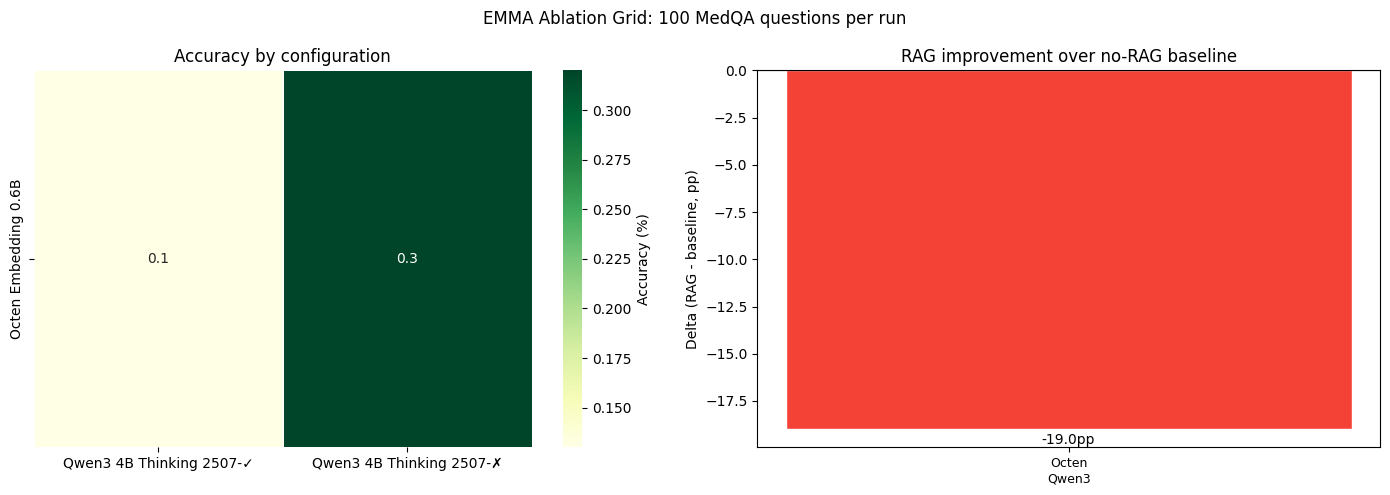

In [16]:
# Visualisation — only rendered when there are at least 2 complete runs
if len(results_df) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: accuracy heatmap
    try:
        hmap = results_df.pivot_table(
            index='Embedding', columns=['LLM', 'RAG'], values='accuracy'
        )
        sns.heatmap(hmap, ax=axes[0], annot=True, fmt='.1f', cmap='YlGn',
                    cbar_kws={'label': 'Accuracy (%)'}, linewidths=0.5)
        axes[0].set_title('Accuracy by configuration')
        axes[0].set_xlabel('')
        axes[0].set_ylabel('')
    except Exception:
        axes[0].text(0.5, 0.5, 'Need more runs for heatmap',
                     ha='center', va='center', transform=axes[0].transAxes)

    # Right: RAG delta bar chart
    if {'✓', '✗'}.issubset(set(results_df['RAG'])):
        colors = ['#4CAF50' if d >= 0 else '#F44336' for d in pivot['Delta (pp)']]
        bars   = axes[1].bar(range(len(pivot)), pivot['Delta (pp)'],
                             color=colors, edgecolor='white')
        labels = pivot.apply(
            lambda r: f"{r['Embedding'].split()[0]}\n{r['LLM'].split()[0]}", axis=1
        )
        axes[1].set_xticks(range(len(pivot)))
        axes[1].set_xticklabels(labels, fontsize=9)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_ylabel('Delta (RAG - baseline, pp)')
        axes[1].set_title('RAG improvement over no-RAG baseline')
        for bar, val in zip(bars, pivot['Delta (pp)']):
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.2 if val >= 0 else -0.8),
                f'{val:+.1f}pp', ha='center', fontsize=10,
            )
    else:
        axes[1].text(0.5, 0.5, 'Need RAG=ON and RAG=OFF runs\nfor delta chart',
                     ha='center', va='center', transform=axes[1].transAxes)

    plt.suptitle(
        f'EMMA Ablation Grid: {N_EVAL} MedQA questions per run',
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()
else:
    print('> Not enough runs to visualise yet!')

## 5. Summary

In [17]:
bench = json.loads(BENCH_PATH.read_text())
runs  = [r for r in bench['runs'] if r.get('status') == 'complete']

if runs:
    best_rag  = max((r for r in runs if r['rag']),
                    key=lambda r: r['accuracy'], default=None)
    best_base = max((r for r in runs if not r['rag']),
                    key=lambda r: r['accuracy'], default=None)

    # Best RAG delta across all paired combinations
    rag_deltas = []
    for r in runs:
        if r['rag']:
            baseline = next(
                (b for b in runs
                 if not b['rag']
                 and b['embedding'] == r['embedding']
                 and b['llm'] == r['llm']),
                None,
            )
            if baseline:
                rag_deltas.append({
                    'config': f"{r['embedding']} + {r['llm']}",
                    'delta':  round(r['accuracy'] - baseline['accuracy'], 1),
                })
    best_delta = max(rag_deltas, key=lambda x: x['delta'], default=None)

    summary_df = pd.DataFrame([
        {'Item': 'Runs complete',             'Value': str(len(runs))},
        {'Item': 'Questions per run',         'Value': str(runs[0]['n_eval'])},
        {'Item': 'Best RAG accuracy',
         'Value': f"{best_rag['accuracy']*100:.1f}%  ({best_rag['embedding']} + {best_rag['llm']})"
                  if best_rag else 'N/A'},
        {'Item': 'Best baseline accuracy',
         'Value': f"{best_base['accuracy']*100:.1f}%  ({best_base['embedding']} + {best_base['llm']})"
                  if best_base else 'N/A'},
        {'Item': 'Best RAG delta',
         'Value': f"{best_delta['delta']:+.1f}pp  ({best_delta['config']})"
                  if best_delta else 'N/A (need paired runs)'},
    ])
    display(summary_df)
else:
    print('> No complete runs yet.')

,Item,Value
0,Runs complete,2
1,Questions per run,100
2,Best RAG accuracy,13.0% (octen-embedding-0.6b + qwen3-4b-thinki...
3,Best baseline accuracy,32.0% (octen-embedding-0.6b + qwen3-4b-thinki...
4,Best RAG delta,-0.2pp (octen-embedding-0.6b + qwen3-4b-think...
